WITHOUT FUZZY

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor   # LightGBM

# =====================
# Load Dataset
# =====================
df = pd.read_csv("/content/Banglore_traffic_Dataset.csv")

# Drop non-numeric columns except target ones
non_numeric = df.select_dtypes(include=['object']).columns
df = df.drop(non_numeric, axis=1, errors="ignore")

# Fill missing values
df = df.ffill()

# Helper function to evaluate model
def evaluate_model(y_true, y_pred, name="Model"):
    print(f"\n🔹 {name}:")
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("R²:", r2_score(y_true, y_pred))

# =====================
# 1) Travel Time Index - Regression
# =====================
if "Travel Time Index" in df.columns:
    features = df.drop(["Travel Time Index"], axis=1, errors="ignore")
    target = df["Travel Time Index"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, target.values, test_size=0.2, shuffle=True, random_state=42
    )

    # LightGBM Model
    lgbm_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    )
    lgbm_model.fit(X_train, y_train)

    y_pred = lgbm_model.predict(X_test)

    evaluate_model(y_test, y_pred, "Travel Time Index (LightGBM Regression)")

# =====================
# 2) Traffic Volume - Regression
# =====================
if "Traffic Volume" in df.columns:
    features = df.drop(["Traffic Volume"], axis=1, errors="ignore")
    target = df["Traffic Volume"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, target.values, test_size=0.2, shuffle=True, random_state=42
    )

    # LightGBM Model
    lgbm_model = LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=-1,
        random_state=42
    )
    lgbm_model.fit(X_train, y_train)

    y_pred = lgbm_model.predict(X_test)

    evaluate_model(y_test, y_pred, "Traffic Volume (LightGBM Regression)")


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 7148, number of used features: 10
[LightGBM] [Info] Start training from score 1.374431


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



🔹 Travel Time Index (LightGBM Regression):
MSE: 0.006108036773875587
RMSE: 0.07815392999635774
MAE: 0.04358048121452948
R²: 0.7725477886122636
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000234 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2178
[LightGBM] [Info] Number of data points in the train set: 7148, number of used features: 10
[LightGBM] [Info] Start training from score 29178.322188

🔹 Traffic Volume (LightGBM Regression):
MSE: 42528.78649141341
RMSE: 206.2250869594032
MAE: 73.78865976677234
R²: 0.9997465500974552


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from lightgbm import LGBMClassifier

if "Congestion Level" in df.columns:
    # Create 3 congestion bins
    df["Congestion_Class"] = pd.cut(
        df["Congestion Level"],
        bins=3,
        labels=["Low", "Medium", "High"],
        include_lowest=True
    )

    features = df.drop(
        ["Travel Time Index", "Congestion Level", "Traffic Volume", "Congestion_Class"],
        axis=1, errors="ignore"
    )
    target = df["Congestion_Class"]

    # Encode target labels
    le = LabelEncoder()
    y_encoded = le.fit_transform(target)

    # Scale features
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    # Train/test split
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_noisy, test_size=0.4, shuffle=True, random_state=42
    )

    # LightGBM classifier (default params)
    model = LGBMClassifier(random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("\n🔹 Congestion Level (LightGBM ):")
    print("Classes:", list(le.classes_))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000280 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1661
[LightGBM] [Info] Number of data points in the train set: 5361, number of used features: 8
[LightGBM] [Info] Start training from score -0.328742
[LightGBM] [Info] Start training from score -2.731834
[LightGBM] [Info] Start training from score -1.536783
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

🔹 Congestion Level (LightGBM ):
Classes: ['High', 'Low', 'Medium']
Confusion Matrix:
 [[1719   38  159]
 [ 439  141  143]
 [ 429   67  440]]
Classification Report:
               precision    recall  f1-score   support

        High       0.66      0.90      0.76      1916
         Low       0.57      0.20      0.29       723
      Medium       0.59      0.47      0.52       936

    accuracy                

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


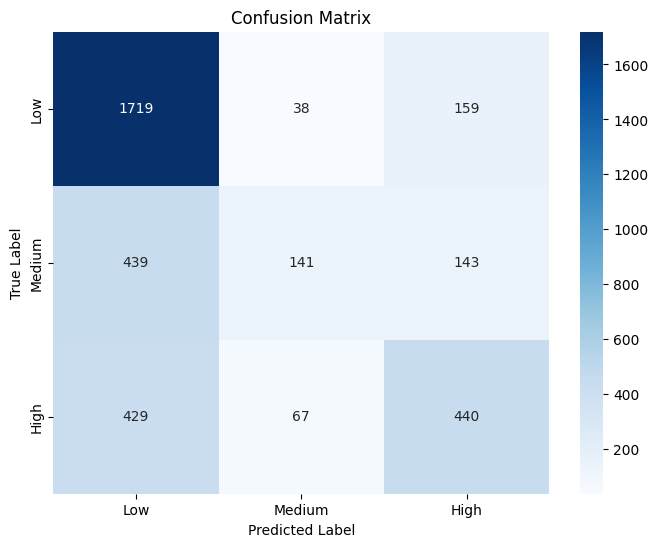

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Your confusion matrix values
cm = [[1719, 38, 159],
      [439, 141, 143],
      [429, 67, 440]]

labels = ["Low", "Medium", "High"]

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


WITH FUZZY LOGIC

In [ ]:
pip install scikit-fuzzy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 10.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import skfuzzy as fuzz
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor

# =====================
# Load Dataset
# =====================
df = pd.read_csv("/content/Banglore_traffic_Dataset.csv")

# Drop non-numeric columns except target ones
non_numeric = df.select_dtypes(include=['object']).columns
df = df.drop(non_numeric, axis=1, errors="ignore")

# Fill missing values
df = df.ffill()

# =====================
# Define Fuzzy Features
# =====================
def add_fuzzy_features(df, column):
    """Create fuzzy features (Low, Medium, High) for a given column."""
    x = df[column].values
    x_min, x_max = np.min(x), np.max(x)

    # Define fuzzy universe
    universe = np.linspace(x_min, x_max, 100)

    # Membership functions
    low = fuzz.trimf(universe, [x_min, x_min, (x_min + x_max) / 2])
    medium = fuzz.trimf(universe, [x_min, (x_min + x_max) / 2, x_max])
    high = fuzz.trimf(universe, [(x_min + x_max) / 2, x_max, x_max])

    # Calculate membership values for each data point
    df[column + "_Low"] = fuzz.interp_membership(universe, low, x)
    df[column + "_Medium"] = fuzz.interp_membership(universe, medium, x)
    df[column + "_High"] = fuzz.interp_membership(universe, high, x)

    return df

# Add fuzzy features for important columns
if "Traffic Volume" in df.columns:
    df = add_fuzzy_features(df, "Traffic Volume")
if "Travel Time Index" in df.columns:
    df = add_fuzzy_features(df, "Travel Time Index")

# =====================
# 1) Travel Time Index - Regression with LightGBM
# =====================
if "Travel Time Index" in df.columns:
    features = df.drop(["Travel Time Index"], axis=1, errors="ignore")
    target = df["Travel Time Index"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    # Train/test split (no sequences for LightGBM)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, target.values, test_size=0.2, shuffle=False
    )

    model = LGBMRegressor(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\n🔹 Travel Time Index (Regression with Fuzzy Features and LightGBM):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))

# =====================
# 2) Traffic Volume - Regression with LightGBM
# =====================
if "Traffic Volume" in df.columns:
    features = df.drop(["Traffic Volume"], axis=1, errors="ignore")
    target = df["Traffic Volume"]

    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(features.values)

    # Train/test split (no sequences for LightGBM)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, target.values, test_size=0.2, shuffle=False
    )

    model = LGBMRegressor(random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("\n🔹 Traffic Volume (Regression with Fuzzy Features and LightGBM):")
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R²:", r2_score(y_test, y_pred))


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002235 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3710
[LightGBM] [Info] Number of data points in the train set: 7148, number of used features: 16
[LightGBM] [Info] Start training from score 1.374854


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



🔹 Travel Time Index (Regression with Fuzzy Features and LightGBM):
MSE: 4.2714363929605115e-08
RMSE: 0.00020667453623899852
MAE: 0.00010421531875922579
R²: 0.9999984104915074
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.007305 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3710
[LightGBM] [Info] Number of data points in the train set: 7148, number of used features: 16
[LightGBM] [Info] Start training from score 29221.081841

🔹 Traffic Volume (Regression with Fuzzy Features and LightGBM):
MSE: 2042.9601449785537
RMSE: 45.19911663936092
MAE: 31.03790699151066
R²: 0.9999876223162998


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002487 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3708
[LightGBM] [Info] Number of data points in the train set: 7148, number of used features: 16
[LightGBM] [Info] Start training from score -0.346653
[LightGBM] [Info] Start training from score -3.276166
[LightGBM] [Info] Start training from score -1.365801
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM Classification Accuracy: 90.77%

Confusion Matrix:
 [[1238   13   34]
 [   0   15   53]
 [  37   28  370]]

Classification Report:
               precision    recall  f1-score   support

        High       0.97      0.96      0.97      1285
         Low       0.27      0.22      0.24        68
      Medium       0.81      0.85      0.83       435

    accuracy                           0.91      1788
   macro avg       0.68      0.68      0.68      1788
weighted avg       0.90      0.91      0.91      1788



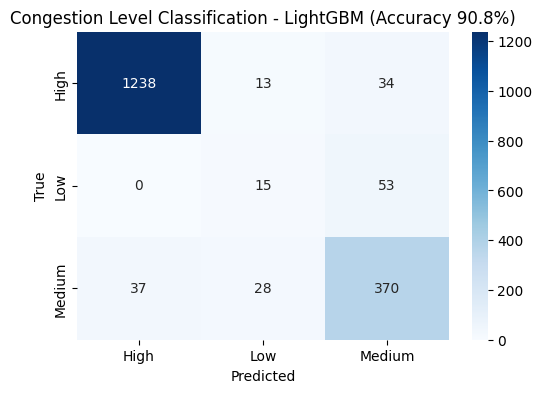

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier

# Assume df is already loaded and has "Congestion Level" column

# Define bins and labels same as your fuzzy logic code
bins_true = [0, 30, 70, 100]
labels = ["Low", "Medium", "High"]

# Create categorical target by binning congestion level
df["Congestion_Class"] = pd.cut(
    df["Congestion Level"],
    bins=bins_true,
    labels=labels,
    include_lowest=True
)

# Features and target
features = df.drop(["Congestion Level", "Congestion_Class"], axis=1, errors="ignore")
target = df["Congestion_Class"]

# Encode target labels to integers
le = LabelEncoder()
y_encoded = le.fit_transform(target)

# Scale features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(features.values)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, shuffle=True, random_state=42
)

# LightGBM Classifier (You can tune parameters here)
model = LGBMClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=1,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

# Evaluation metrics
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=le.classes_)

print(f"LightGBM Classification Accuracy: {acc*100:.2f}%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", report)

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Congestion Level Classification - LightGBM (Accuracy {acc*100:.1f}%)")
plt.show()
